#**Does Biomedical Pretraining Matter for Clinical NER?**
###**A From-Scratch vs. Fine Tuned Comparison**

Clinical text, discharge summaries, progress notes, and case reports are critical for a patient's medical record. This data contains symptoms, diagnoses, medications, and procedures as unstructured free text, which makes it hard to search, aggregate, or feed into any downstream system. Named Entity Recognition (NER) is the general first step for turning this free text into structured data by tagging spans of text with what kind of clinical concept they represent. The applications of this vary, from pulling structured data out of patients' electronic health records, to building research cohorts from case reports at bigger scales.

In this notebook, I investigate: how much of a model's ability to do clinical NER actually comes from pretraining on clinical on biomedial text, as compared to just having a transformer architecture trained on the task itself?
In my attempt to answer this question, I built a transformer encoder from scratch, multi-head self attention, feedforward layers, pre-norm residual blocks with no pretrained weights, and trained it directly on the target task.
<br>
I then fine tuned Bio_ClinicalBERT, which is pretraind on clinical text specifically, on the exact same data, split and label set such that the only real variable between the models is the difference in pretraining.

<br>
The dataset is MACCROBAT ~200 annotated clinical case reports covering 41 BIO tagged entity types. This is too small of a dataset to train anything from scratch, making it a clean test of exactly the impact pretraining has in a low data clinical setting.

In [ ]:
!pip install -U transformers datasets seqeval accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.9 MB/s eta 0:00:00


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU — check Runtime > Change runtime type > T4 GPU")

GPU available: True
Tesla T4


In [ ]:
#Loading the MACCROBAT dataset from huggingface:

from datasets import load_dataset

!wget -O maccrobat.zip "https://ndownloader.figshare.com/articles/9764942/versions/2"
!unzip -q maccrobat.zip -d maccrobat_data

--2026-07-17 06:01:05--  https://ndownloader.figshare.com/articles/9764942/versions/2
Resolving ndownloader.figshare.com (ndownloader.figshare.com)... 52.210.243.135, 54.78.134.102, 34.250.120.167, ...
Connecting to ndownloader.figshare.com (ndownloader.figshare.com)|52.210.243.135|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2135369 (2.0M) [application/zip]
Saving to: ‘maccrobat.zip’

maccrobat.zip       100%[===================>]   2.04M  2.01MB/s    in 1.0s    

2026-07-17 06:01:07 (2.01 MB/s) - ‘maccrobat.zip’ saved [2135369/2135369]



In [ ]:
#dataset check:
!unzip -q maccrobat_data/MACCROBAT2020.zip -d maccrobat_data/2020
!find maccrobat_data/2020 -type f | head -20
!find maccrobat_data/2020 -type f | wc -l

maccrobat_data/2020/28353596.ann
maccrobat_data/2020/26530965.ann
maccrobat_data/2020/28250304.txt
maccrobat_data/2020/26664317.txt
maccrobat_data/2020/22515939.ann
maccrobat_data/2020/26405496.ann
maccrobat_data/2020/28057913.txt
maccrobat_data/2020/28196820.ann
maccrobat_data/2020/23035161.txt
maccrobat_data/2020/26584481.txt
maccrobat_data/2020/26444414.ann
maccrobat_data/2020/24526194.ann
maccrobat_data/2020/28248891.txt
maccrobat_data/2020/20671919.ann
maccrobat_data/2020/25759562.ann
maccrobat_data/2020/23312850.ann
maccrobat_data/2020/26675562.ann
maccrobat_data/2020/28151860.txt
maccrobat_data/2020/23897372.txt
maccrobat_data/2020/28202865.ann
400


In [ ]:
import os, re, glob

def parse_ann_file(ann_path):
    entities = []
    with open(ann_path, encoding="utf-8") as f:
        for line in f:
            if not line.startswith("T"):
                continue  # skip relation (R) and attribute (A) lines
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            label_and_span, text = parts[1], parts[2]
            label_and_span = label_and_span.split(";")[0]  # drop discontinuous-span extras, keep it simple
            label, start, end = label_and_span.split(" ")[0], *label_and_span.split(" ")[1:3]
            entities.append({"text": text, "label": label, "start": int(start), "end": int(end)})
    return entities

txt_files = sorted(glob.glob("maccrobat_data/**/*.txt", recursive=True))
documents = []
for txt_path in txt_files:
    ann_path = txt_path.rsplit(".", 1)[0] + ".ann"
    if not os.path.exists(ann_path):
        continue
    with open(txt_path, encoding="utf-8") as f:
        full_text = f.read()
    documents.append({"full_text": full_text, "ner_info": parse_ann_file(ann_path)})

print(len(documents), "documents loaded")

example = documents[0]  #1st element of the dataset

print(example["full_text"])
print(example["ner_info"])


200 documents loaded
CASE: A 28-year-old previously healthy man presented with a 6-week history of palpitations.
The symptoms occurred during rest, 2–3 times per week, lasted up to 30 minutes at a time and were associated with dyspnea.
Except for a grade 2/6 holosystolic tricuspid regurgitation murmur (best heard at the left sternal border with inspiratory accentuation), physical examination yielded unremarkable findings.
An electrocardiogram (ECG) revealed normal sinus rhythm and a Wolff– Parkinson– White pre-excitation pattern (Fig.1: Top), produced by a right-sided accessory pathway.
Transthoracic echocardiography demonstrated the presence of Ebstein's anomaly of the tricuspid valve, with apical displacement of the valve and formation of an “atrialized” right ventricle (a functional unit between the right atrium and the inlet [inflow] portion of the right ventricle) (Fig.2).
The anterior tricuspid valve leaflet was elongated (Fig.2C, arrow), whereas the septal leaflet was rudimentar

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[459, 610, 681, 487, 706, 832, 903, 295, 488, 452, 509, 789, 788, 703, 475, 322, 819, 339, 1059, 390, 629, 281, 550, 524, 772, 594, 547, 512, 1076, 1087, 913, 541, 517, 544, 607, 509, 700, 768, 622, 963, 731, 1084, 558, 366, 573, 526, 820, 678, 480, 1000, 779, 630, 673, 471, 609, 524, 410, 595, 740, 511, 982, 850, 296, 950, 421, 792, 731, 715, 424, 900, 442, 322, 833, 813, 1069, 443, 974, 463, 554, 737, 708, 229, 886, 651, 916, 567, 952, 750, 488, 342, 786, 615, 853, 476, 912, 702, 671, 577, 778, 626, 330, 586, 579, 490, 406, 1566, 573, 805, 461, 403, 602, 894, 573, 793, 476, 892, 717, 401, 575, 1052, 1518, 669, 623, 530, 1088, 403, 940, 736, 641, 952, 940, 706, 1351, 857, 846, 533, 966, 1312, 490, 1400, 718, 445, 1068, 740, 661, 920, 1107, 707, 806, 854, 826, 397, 378, 827, 494, 1021, 1042, 283, 628, 776, 751, 680, 1226, 586, 994, 886, 1341, 638, 658, 579, 1111, 994, 675, 342, 1047, 883, 342, 567, 681, 863, 685, 479, 891, 867, 652, 610, 847, 1289, 771, 1366, 526, 1401, 740, 1527, 1251

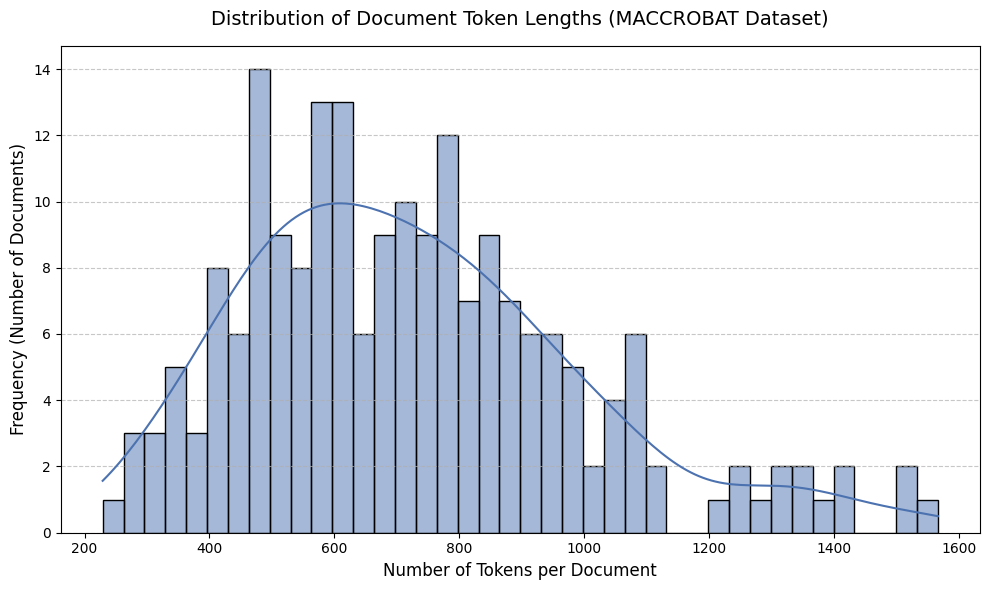

Max token length: 1566
Min token length: 229
Average token length: 724.19


In [ ]:
#visualizing samples from the dataset ->
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")


# print(documents)

lengths = [
    len(tokenizer(doc['full_text'], truncation=False)['input_ids'])
    for doc in documents
]

print(lengths)
plt.figure(figsize=(10, 6))
sns.histplot(lengths, bins=40, kde=True, color='#4C72B0', edgecolor='black')

plt.title('Distribution of Document Token Lengths (MACCROBAT Dataset)', fontsize=14, pad=15)
plt.xlabel('Number of Tokens per Document', fontsize=12)
plt.ylabel('Frequency (Number of Documents)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print(f"Max token length: {max(lengths)}")
print(f"Min token length: {min(lengths)}")
print(f"Average token length: {sum(lengths) / len(lengths):.2f}")

In [ ]:
#imports

import torch
import torch.nn as nn
from dataclasses import dataclass
import math


In [ ]:
#Building the NER Model out of a Transformer encoder

#Setup
@dataclass
class Configuration:

  num_labels: int = 83
  max_sequence_length: int = 800 #average was 724.19
  # vocab_size: int = 30000 - instead of hardcoding - we'll pull vocab
  #size directly from the tokenizer to embedding layer / token id alignment errors

  tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
  vocab_size: int = tokenizer.vocab_size
  pad_token_id: int = 0
  seed: int = 42

  n_dim: int = 128 #model dimensions
  n_heads: int = 8 #number of attention heads
  n_layers: int = 2 #number of transformer blocks

  head_size = n_dim // n_heads
  dropout: float = 0.1
  learning_rate: float = 0.001  #changed from 0.0001

  device = "cuda" if torch.cuda.is_available() else "cpu"


  def __post_init__(self):
    self.head_size = self.n_dim // self.n_heads
    self.device = "cuda" if torch.cuda.is_available() else "cpu"


#NERTransformer Build & Structure
I started from an encoder I built for next-token prediction which used causal masking to stop each token from attending to future ones. NER on the other hand, requires bidirectional context to tag a token correctly - a word before and after an entity, especially in clinical contexts, can signal what it is. So I removed causal masking entirely and kept padded masking, preventing the model from wasting attention on filler tokens that carry no information.

<br>
I reused Multi-head Self Attention from my previous encoder, splitting my single q, k,v projection into multiple heads to run in parallel and capture different dimensions of detail from the text, resulting in a slightly more rich semantic understanding of the context later on.

<br>
After attention mixes information across tokens, each token position runs through a small feed forward network, which is a linear layer of up to 512 dimensions (128*4 (4 is the standard expansion ratio from "Attention is All You Need"), then a GELU nonlinear layer, and another linear layer, compressing the dimensions back down to 128. This expansion allows for the model to represent complex nonlinear combinations of features before compression.

<br>

Each sublayer, attention, and feedforward is wrapped in a residual connection with LayerNorm applied before sublayer runs (prenorm, not postnorm as seen in "Attention is all You Need"). I made this change because I was training from scratch on a small dataset, with no pretrained initialization, and it helped regulate gradients during training & prevent vanishing gradients. Prenorm normalizes the running values before they pass through each layer and makes the learning rate less sensitive to learning rate choices - which I ran into directly during warmup and scheduling.

<br>

The OutputHead class implements a single linear layer projecting from the model's 128 dimension representation down to 83 classes, one for each BIO tag. Since NER is a per token classification task, the output Head layer runs independently at every token position, giving each token its own probability distribution over 83 possible tags, and outputs raw logits.
<br>


In [ ]:
class MultiHeadSelfAttention(nn.Module):
# Multi head self attention block with a single combined QKV projection

    def __init__(self, cfg):
      super().__init__()

      self.n_heads = cfg.n_heads
      self.n_dim = cfg.n_dim

      self.n_layers = cfg.n_layers
      self.head_size = cfg.head_size

      self.qkv = nn.Linear(cfg.n_dim, 3 * cfg.n_dim) #combined Q,K,V projection
      self.proj = nn.Linear(cfg.n_dim, cfg.n_dim) # glues heads back together


      #attention dropout layer
      self.attn_drop = nn.Dropout(cfg.dropout)

      #residual dropout layer
      self.resid_drop = nn.Dropout(cfg.dropout)

    def forward(self, x, pad_mask = None):
      #forward pass

      #B = batch, T = sequence length, C = n_dim
      B, T, C = x.shape
      H, D = self.n_heads, self.head_size

      #split qkv into heads
      qkv = self.qkv(x) #B,T,3*C
      q, k, v = qkv.split(self.n_dim, dim = -1)

      q = q.view(B, T, H, D).transpose(1,2)
      k = k.view(B, T, H, D).transpose(1, 2)
      v = v.view(B, T, H, D).transpose(1, 2)

      scores = q @ k.transpose(-2, -1) / math.sqrt(D)

      #adding a padding mask for more accuracy
      if pad_mask is not None:
        mask = pad_mask[:, None, None, :]
        scores = scores.masked_fill(~mask, float("-inf"))

      attn = torch.softmax(scores, dim = -1)
      attn = self.attn_drop(attn)

      out = attn @ v
      out = out.transpose(1, 2).reshape(B, T, C)  #merging the heads back to B, T, C

      out = self.proj(out)
      out = self.resid_drop(out)

      return out

In [ ]:
#Output head -> final layer

class OutputHead(nn.Module):
  # turns each token's hidden vector into scores
  #for 83 biotags. Runs once after every encoder block

  def __init__(self, cfg):
    super().__init__()
    self.proj = nn.Linear(cfg.n_dim, cfg.num_labels)

  def forward(self, x):
    return self.proj(x)   #B, T, n_dim ->  B, T, num_labels

In [ ]:
#FFNN

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    hidden = 4*cfg.n_dim #4* -> standard

    self.net = nn.Sequential(
        nn.Linear(cfg.n_dim, hidden),
        nn.GELU(),
        nn.Linear(hidden, cfg.n_dim),
        nn.Dropout(cfg.dropout)
    )

  def forward(self, x):
    return self.net(x)

In [ ]:
#Encoder

class Encoder(nn.Module):

  def __init__(self, cfg):
    super().__init__()

  #normalization block
    self.norm1 = nn.LayerNorm(cfg.n_dim)
    self.norm2 = nn.LayerNorm(cfg.n_dim)

    self.attention = MultiHeadSelfAttention(cfg)
    self.FF = FeedForward(cfg)

    self.dropout = nn.Dropout(cfg.dropout)

  def forward(self, x, pad_mask = None):
    x = x + self.attention(self.norm1(x), pad_mask)  #attention layer
    x = x + self.FF(self.norm2(x))   #feedforward layer

    return x


In [ ]:
cfg = Configuration()
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
cfg.vocab_size = tokenizer.vocab_size
cfg.pad_token_id = tokenizer.pad_token_id



In [ ]:
#Turning each document into aligned Token ids and BIO labels
#SPAN: literally a span that indexes the starting and ending indices of a word
#MACCROBAT's ner_info returns spans for every labeled entity + what type it is
#We use offset_mapping as the tokenizer that keeps track of tokens that are split on
#subword pieces - keeps track of this using spans.
#Checking token's span against entity's span: for each token, we check if the token's
#character range falls inside the entity's character range.

entity_types = sorted({ent["label"] for doc in documents for ent in doc["ner_info"]})
print(len(entity_types), entity_types)

tag_list = ["O"] + [f"{prefix} - {etype}" for etype in entity_types for prefix in ("B", "I")]
tag2id = {tag: i for i, tag in enumerate(tag_list)}

def encode_doc(doc, tokenizer, cfg):
  encoding = tokenizer(
      doc["full_text"],
      truncation = True,
      max_length =cfg.max_sequence_length,
      padding = "max_length",
      return_offsets_mapping = True
  )

  offsets = encoding.pop("offset_mapping")

  labels = [tag2id["O"]] * len(offsets)

  for ent in doc["ner_info"]:
    start, end, etype = ent["start"], ent["end"], ent["label"]
    first_token = True

    for i, (tok_start, tok_end) in enumerate(offsets):
      if tok_start == tok_end:
        continue

      #BIO Tagging process:
      if tok_start >= start and tok_end <=end:
        prefix = "B" if first_token else "I"
        labels[i] = tag2id[f"{prefix} - {etype}"]
        first_token = False

  labels = [-100 if s==e else l for (s, e), l in zip(offsets, labels)]
  encoding["labels"] = labels

  return encoding



41 ['Activity', 'Administration', 'Age', 'Area', 'Biological_attribute', 'Biological_structure', 'Clinical_event', 'Color', 'Coreference', 'Date', 'Detailed_description', 'Diagnostic_procedure', 'Disease_disorder', 'Distance', 'Dosage', 'Duration', 'Family_history', 'Frequency', 'Height', 'History', 'Lab_value', 'Mass', 'Medication', 'Nonbiological_location', 'Occupation', 'Other_entity', 'Other_event', 'Outcome', 'Personal_background', 'Qualitative_concept', 'Quantitative_concept', 'Severity', 'Sex', 'Shape', 'Sign_symptom', 'Subject', 'Texture', 'Therapeutic_procedure', 'Time', 'Volume', 'Weight']


In [ ]:
id2label = {0: "O"}
idx = 1

for etype in entity_types:
  id2label[idx] = f"B-{etype}"
  id2label[idx + 1] = f"I-{etype}"

  idx += 2

In [ ]:
from torch.utils.data import Dataset, DataLoader

#train-test split:
import random

random.seed(cfg.seed)
shuffled = documents.copy()
random.shuffle(shuffled)

split_idx = int(0.85 * len(shuffled))
train_docs = shuffled[:split_idx]
val_docs = shuffled[split_idx:]

print(len(train_docs), len(val_docs))


#creating the final dataset:
class NERDataset(Dataset):
  def __init__(self, documents, tokenizer, cfg):
    self.examples = [encode_doc(d, tokenizer, cfg) for d in documents]
  def __len__(self):
    return len(self.examples)

  def __getitem__(self, idx):
    ex = self.examples[idx]
    result = {
        "input_ids":torch.tensor(ex["input_ids"]),
        "attention_mask": torch.tensor(ex["attention_mask"]),
        "labels": torch.tensor(ex["labels"])
    }

    return result


170 30


In [ ]:
#constructing full transformer

class NERTransformer(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb = nn.Embedding(cfg.vocab_size, cfg.n_dim, padding_idx = cfg.pad_token_id)
    self.pos_emb = nn.Embedding(cfg.max_sequence_length, cfg.n_dim)

    self.dropout = nn.Dropout(cfg.dropout)
    self.layers = nn.ModuleList([Encoder(cfg) for _ in range(cfg.n_layers)])

    self.output_head = OutputHead(cfg)

  def forward(self, input_ids, attention_mask = None):
    B, T = input_ids.shape
    positions = torch.arange(T, device = input_ids.device).unsqueeze(0)
    #unsqueeze(0) adds a batch dimension of 1 at the start of the tensor's shape
    #standard way to generate absolute positional embeddings for a single sequence in transformer models
    x = self.token_emb(input_ids) + self.pos_emb(positions)
    x = self.dropout(x)

    pad_mask = attention_mask.bool() if attention_mask is not None else None
    for layer in self.layers:
      x = layer(x, pad_mask)

    return self.output_head(x)

#Testing Pipeline before Training
Before running the pipeline on all 144 documents, I use a handful of documents and get the pipeline to memorize them correctly to rule out bugs and get everything running smoothly.
<br>
This overfit test yielded a memorization accuracy of ~97%, confirming that labels are correctly aligned and loss computation is correct.

In [ ]:
#Overfit test to make sure nothing is wrong with the pipeline:
import dataclasses
overfit_cfg = dataclasses.replace(cfg, dropout = 0.0)
#making a copy of the config dataset but with dropout 0

#select data -> create dataset -> create dataLoader
overfit_docs = train_docs[:5]
overfit_dataset = NERDataset(overfit_docs, tokenizer, cfg)
overfit_loader = DataLoader(overfit_dataset, batch_size = 5, shuffle = False)


model = NERTransformer(cfg).to(cfg.device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay = 0.0)
loss_fn = nn.CrossEntropyLoss(ignore_index = -100)

num_epochs = 300

model.train()


for epoch in range(num_epochs):
  epoch_loss = 0.0
  for batch in overfit_loader:
    input_ids = batch["input_ids"].to(overfit_cfg.device)
    labels = batch["labels"].to(overfit_cfg.device)

    pad_mask = batch["attention_mask"].to(overfit_cfg.device)

    optimizer.zero_grad()
    logits = model(input_ids, pad_mask)
    loss = loss_fn(logits.view(-1, 83), labels.view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    epoch_loss += loss.item()

    preds = logits.argmax(dim = -1)
    valid = labels != -100
    acc = (preds[valid] == labels[valid]).float().mean().item()

  if epoch % 20 == 0:
    print(f"epoch {epoch}, loss: {epoch_loss / len(overfit_loader):.4f}, acc: {acc:.4f}")

epoch 0, loss: 4.8159, acc: 0.0116
epoch 20, loss: 2.2795, acc: 0.3979
epoch 40, loss: 1.6568, acc: 0.5266
epoch 60, loss: 0.9921, acc: 0.7159
epoch 80, loss: 0.3288, acc: 0.9172
epoch 100, loss: 0.0767, acc: 0.9854
epoch 120, loss: 0.0406, acc: 0.9906
epoch 140, loss: 0.0243, acc: 0.9946
epoch 160, loss: 0.0214, acc: 0.9960
epoch 180, loss: 0.0139, acc: 0.9960
epoch 200, loss: 0.0134, acc: 0.9962
epoch 220, loss: 0.0120, acc: 0.9968
epoch 240, loss: 0.0118, acc: 0.9957
epoch 260, loss: 0.0088, acc: 0.9981
epoch 280, loss: 0.0075, acc: 0.9984


#Training and Validation


*   Optimizer: AdamW, weight_decay 0.01 -> Initially 0.03 prevented learning severely given the size of the dataset, so reduced to 0.01
*   Learning Rate + Warmup: I used a linear warmup + linear decay, and increased LR over the first 10% of training steps before decaying to 0. I did this because training a transformer from scratch results in initial gradients being too large and noisy, so using a high LR straight up causes the loss to bounce instead of decrease smoothly.

*   I got a bug in the scheduler twice, where total step count started getting computed from a stale epoch value, and resulted in the LR decaying to 0 in the middle of training, and getting identical loss for multiple consecutive epochs.
*  Gradient Clipping: I added clip_grad_norm with max_norm = 1.0 to help prevent exploding gradients - generally used for transformers without pretraining.






In [ ]:
#Setting up dataloaders

train_loader = DataLoader(NERDataset(train_docs, tokenizer, cfg), batch_size = 8, shuffle = True)

val_loader = DataLoader(NERDataset(val_docs, tokenizer, cfg), batch_size=32, shuffle=False, num_workers=0)

In [ ]:
#FINAL training and validation loop
from transformers import get_linear_schedule_with_warmup

model = NERTransformer(cfg).to(cfg.device)
num_epochs = 60 #increased from 10

optimizer = torch.optim.AdamW(model.parameters(), lr = 5e-4, weight_decay = 0.01)
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps) #10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps = warmup_steps, num_training_steps = total_steps

)

loss_fn = nn.CrossEntropyLoss(ignore_index = -100)

model.train()

for epoch in range(num_epochs):
  total_loss = 0

  for batch in train_loader:
    input_ids = batch["input_ids"].to(cfg.device)
    attention_mask = batch["attention_mask"].to(cfg.device)
    labels = batch["labels"].to(cfg.device)

    logits = model(input_ids, attention_mask)
    loss = loss_fn(logits.view(-1, cfg.num_labels), labels.view(-1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()
    total_loss += loss.item()

    preds = logits.argmax(dim = -1)
    valid = labels != -100
    acc = (preds[valid] == labels[valid]).float().mean().item()


  model.eval()
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for batch in val_loader:
      input_ids = batch["input_ids"].to(cfg.device)
      attention_mask = batch["attention_mask"].to(cfg.device)
      labels = batch["labels"].to(cfg.device)

      logits = model(input_ids, attention_mask)
      loss = loss_fn(logits.view(-1, cfg.num_labels), labels.view(-1))
      val_loss += loss.item()

      preds = logits.argmax(dim = -1)
      valid = labels != -100
      val_correct += (preds[valid] == labels[valid]).sum().item()
      val_total += valid.sum().item()

  avg_val_loss = val_loss / len(val_loader)

  #checkpoint saving -> lowest validation loss:
  best_val_loss = float("inf")
  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    torch.save(model.state_dict(), "best_model.pt")

  val_acc = val_correct / val_total



  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}, acc: {acc:.4f}, \navg val loss: {avg_val_loss}, val acc:{val_acc}")
  print(f"current LR: {optimizer.param_groups[0]['lr']:.8f}")



Epoch 1/60, Loss: 4.413767337799072, acc: 0.0297, 
avg val loss: 4.413767337799072, val acc:0.05027932960893855
current LR: 0.00008333
Epoch 2/60, Loss: 3.2902324199676514, acc: 0.2984, 
avg val loss: 3.2902324199676514, val acc:0.3900353437464371
current LR: 0.00016667
Epoch 3/60, Loss: 2.7220401763916016, acc: 0.3427, 
avg val loss: 2.7220401763916016, val acc:0.37726599019496065
current LR: 0.00025000
Epoch 4/60, Loss: 2.500323534011841, acc: 0.3711, 
avg val loss: 2.500323534011841, val acc:0.4002964314217307
current LR: 0.00033333
Epoch 5/60, Loss: 2.380770444869995, acc: 0.3987, 
avg val loss: 2.380770444869995, val acc:0.4166001596169194
current LR: 0.00041667
Epoch 6/60, Loss: 2.282304048538208, acc: 0.4045, 
avg val loss: 2.282304048538208, val acc:0.42680424124957245
current LR: 0.00050000
Epoch 7/60, Loss: 2.2149124145507812, acc: 0.4412, 
avg val loss: 2.2149124145507812, val acc:0.4366092805837419
current LR: 0.00049074
Epoch 8/60, Loss: 2.1716015338897705, acc: 0.5099, 
a

In [ ]:
from seqeval.metrics import classification_report
#We compare the metric accuracies of our from-scratch model using seqeval so they are comparable to
#BIO_ClinicalBERT metric accuracies

def get_entity_level_predictions(model, loader, device):

  model.eval()
  all_true_tags = []
  all_pred_tags = []

  with torch.no_grad():
    for batch in loader:
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      logits = model(input_ids, attention_mask)
      preds = logits.argmax(dim = -1)

      for i in range(labels.size(0)):
        true_seq, pred_seq = [], []
        for j in range(labels.size(1)):
          label_id = labels[i,j].item()
          if label_id == -100:
            continue

          true_seq.append(id2label[label_id])
          pred_seq.append(id2label[preds[i, j].item()])

        all_true_tags.append(true_seq)
        all_pred_tags.append(pred_seq)

  return all_true_tags, all_pred_tags

In [ ]:
#running seqeval metric accuracies on val_loader using best checkpoint

model.load_state_dict(torch.load("best_model.pt"))

true_tags, pred_tags = get_entity_level_predictions(model, val_loader, cfg.device)
report = classification_report(true_tags, pred_tags)

with open("classification_report.txt", "w") as f:
    f.write(report)

print(report)

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                        precision    recall  f1-score   support

              Activity       0.00      0.00      0.00        18
        Administration       0.18      0.36      0.24        11
                   Age       0.75      0.87      0.81        31
                  Area       0.00      0.00      0.00         2
  Biological_structure       0.07      0.19      0.10       381
        Clinical_event       0.66      0.59      0.62        83
                 Color       0.00      0.00      0.00         4
           Coreference       0.00      0.00      0.00        62
                  Date       0.02      0.04      0.03        70
  Detailed_description       0.06      0.10      0.07       382
  Diagnostic_procedure       0.07      0.24      0.11       536
      Disease_disorder       0.01      0.04      0.02       134
              Distance       0.00      0.00      0.00        13
                Dosage       0.00      0.00      0.00        28
              Duration       0.05      

<b>Model Limitations - Classification Report</b>
So training a transformer (without pretraining on text) from scratch on a dataset size of less than 200 was expected to have a low accuracy. Our results here show a token accuracy of ~52%, with a Micro-F1 score of 0.12

We do see, that the model has learned some things. Entities such as Sex(F1 = 0.90), Age(F1=0.76), Clinical_event(0.58), Severity(0.59) are short and structurally distinct -allowing for our small model with no pretraining to easily pick them up from a small dataset.

The entities that are doing badly include Sign_symptoms (F1= 0.14), Diagnostic_procedure (F1 = 0.11), Biological_structure (F1 = 0.09), Lab_value(F1 = 0.11)

<h3>Fine-Tuning Bio_ClinicalBERT</h3>

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import dataclasses

fine_tune_cfg = dataclasses.replace(cfg, max_sequence_length = 512)
#making a copy of the config dataset but with max_sequence_length = 512 instead of 800
#to align with Bio_ClinicalBERT

bert_tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

bert_model = AutoModelForTokenClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT",
    num_labels = len(tag2id),
    id2label = id2label,
    label2id = tag2id
).to(fine_tune_cfg.device)

bert_train_dataset = NERDataset(train_docs, bert_tokenizer, fine_tune_cfg)
bert_val_dataset = NERDataset(val_docs, bert_tokenizer, fine_tune_cfg)

bert_train_loader = DataLoader(bert_train_dataset, batch_size = 8, shuffle = True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size = 32, shuffle = False)

#Lr = 2e-5 -> much lower lr as compared to from-scratch NERTransformer for fine tuning
#not learning from scratch
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr= 2e-5, weight_decay = 0.01)

#num_epochs = 4 -> much lower than from-scratch NERTransformer (60) because
#pretrained model converges fast on fine tuning tasks. More epochs, given that our
#dataset size is also small (144) would lead to overfitting.
bert_num_epochs = 16  #bumped to 16
bert_total_steps = len(bert_train_loader) * bert_num_epochs
bert_warmup_steps = int(0.1 * bert_total_steps)

bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer, num_warmup_steps = bert_warmup_steps, num_training_steps = bert_total_steps
)
#We don't call manual loss function because HuggingFace already has a built in
#cross entropy calculation in its forward function


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
best_bert_val_loss = float("inf")

for epoch in range(bert_num_epochs):
  bert_model.train()
  total_loss = 0

  for batch in bert_train_loader:
    input_ids = batch["input_ids"].to(fine_tune_cfg.device)
    attention_mask = batch["attention_mask"].to(fine_tune_cfg.device)
    labels = batch["labels"].to(fine_tune_cfg.device)

    outputs = bert_model(input_ids = input_ids, attention_mask = attention_mask, labels = labels)
    loss = outputs.loss

    bert_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
    bert_optimizer.step()
    bert_scheduler.step()

    total_loss += loss.item()

  avg_train_loss = total_loss / len(bert_train_loader)

  bert_model.eval()

  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for batch in bert_val_loader:
      input_ids = batch["input_ids"].to(fine_tune_cfg.device)
      attention_mask = batch["attention_mask"].to(fine_tune_cfg.device)
      labels = batch["labels"].to(cfg.device)
      outputs = bert_model(input_ids = input_ids, attention_mask = attention_mask, labels = labels)
      preds = outputs.logits.argmax(dim=-1)
      valid = labels != -100
      val_correct += (preds[valid] == labels[valid]).sum().item()
      val_total += valid.sum().item()

      val_loss += outputs.loss.item()

  avg_val_loss = val_loss / len(bert_val_loader)

  print(f"Epoch {epoch+1}/{bert_num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_correct/val_total}")

  if avg_val_loss < best_bert_val_loss:
    best_bert_val_loss = avg_val_loss
    torch.save(bert_model.state_dict(), "best_bert_model.pt")

Epoch 1/16, Train Loss: 3.9798, Val Loss: 3.0625, Val Acc: 0.40196767392832045
Epoch 2/16, Train Loss: 2.7430, Val Loss: 2.2673, Val Acc: 0.4647224174279691
Epoch 3/16, Train Loss: 2.0959, Val Loss: 1.7981, Val Acc: 0.5749824314827828
Epoch 4/16, Train Loss: 1.6734, Val Loss: 1.4461, Val Acc: 0.6557273366127899
Epoch 5/16, Train Loss: 1.3619, Val Loss: 1.2264, Val Acc: 0.7030217849613493
Epoch 6/16, Train Loss: 1.1437, Val Loss: 1.0972, Val Acc: 0.7301475755446241
Epoch 7/16, Train Loss: 1.0034, Val Loss: 0.9875, Val Acc: 0.7549543218552354
Epoch 8/16, Train Loss: 0.9111, Val Loss: 0.9398, Val Acc: 0.7669711876317639
Epoch 9/16, Train Loss: 0.8353, Val Loss: 0.9018, Val Acc: 0.7739985945186226
Epoch 10/16, Train Loss: 0.7740, Val Loss: 0.8998, Val Acc: 0.7748418833450457
Epoch 11/16, Train Loss: 0.7262, Val Loss: 0.8856, Val Acc: 0.7765987350667604
Epoch 12/16, Train Loss: 0.6960, Val Loss: 0.8719, Val Acc: 0.7806043569922698
Epoch 13/16, Train Loss: 0.6641, Val Loss: 0.8647, Val Acc: 

In [ ]:
#classification report on fine-tuned Bio_ClinicalBERT!!

bert_model.load_state_dict(torch.load("best_bert_model.pt"))

class LogitsWrapper:
    def __init__(self, model):
        self.model = model
    def eval(self):
        self.model.eval()
    def __call__(self, input_ids, attention_mask):
        return self.model(input_ids, attention_mask).logits

true_tags, pred_tags = get_entity_level_predictions(
    LogitsWrapper(bert_model),
    bert_val_loader,
    fine_tune_cfg.device
)
report = classification_report(true_tags, pred_tags)

with open("bert_classification_report.txt", "w") as f:
    f.write(report)

print(report)

                        precision    recall  f1-score   support

              Activity       0.00      0.00      0.00        18
        Administration       0.00      0.00      0.00         8
                   Age       0.78      0.90      0.84        31
                  Area       0.00      0.00      0.00         2
  Biological_structure       0.56      0.74      0.64       333
        Clinical_event       0.73      0.70      0.71        69
                 Color       0.00      0.00      0.00         4
           Coreference       0.00      0.00      0.00        52
                  Date       0.38      0.59      0.46        59
  Detailed_description       0.33      0.47      0.39       325
  Diagnostic_procedure       0.62      0.77      0.69       410
      Disease_disorder       0.29      0.42      0.34       120
              Distance       0.07      0.09      0.08        11
                Dosage       0.60      1.00      0.75        18
              Duration       0.21      

##**Comparative Analysis**
Its expected that the pretrained BIO_ClinicalBERT model wins: Micro F1 scores jump from 0.12->0.54,while weighted F1 increases from 0.13-> 0.53.

Since BERT was pretrained on thousands of biomedical and clinical documents, its biggest advantage lies in the fact that it can detect core clinical entity types more effectively, and the difference is significant. Especially with arguably the most important entities, medication and dosage.

Entity vs. F1 scores:

*   Diagnostic_procedure -> scratch: 0.11, bert: 0.67
*   Lab_value -> scratch: 0.13, bert:0.62
*   Sign_symptom -> scratch: 0.13, bert: 0.60
*   Biological_structure -> scratch: 0.10, bert:0.64
*   Medication -> scratch: 0.02, bert: 0.67
*   Dosage -> scratch: 0.00, bert: 0.72
*   Disease_disorder: scratch: 0.01, bert: 0.34

Looking at the metrics for the scratch model, we can see that for high support tags like Diagnostic_procedure, Lab_value, and Biological_structure, precision is low as compared to recall, which is indicative of a model that is over predicting common tags by flagging a lot of false positives. Contrastingly, BERT's precision and recall scores are more balanced on the same tags showing that its purposely discriminating between them rather than guessing broadly.

Despite the expected results, there is one exception: For Severity, the scratch model beats BERT with respective f1 scores of 0.58 vs 0.00. This is probably because the BERT model has a truncation of 512, when the average document length is ~720, meaning context is lost due to loss of document length.
<br>
Taken together, the results show that biomedical pretraining is more a precondition for reliably extracting medical entities, rather than a simple marginal advantage.
We see that pretraining roughly quadruples entity-level F1 on this task, but the 512 token trunction caveat for BERT still remains. The one entity - Severity- where the scratch model wins is better read as a limitation of the comparison rather than an actual architectural edge over BERT, whose 512 token truncation cuts off content on documents averaging ~720 tokens.

<br>
A next step for this could  be to add chunked inference to recover the missing context for finetuned BERT, or adding a CRF (Conditional Random Field) layer on top of either of the models to help enforce valid BIO transitions, and fix uncertain predictions.








